# FETI methods

Finite Element Tearing and Interconnection.

As the name says, we break the global (finite element) system apart, and then reenforce continuity via Lagrange parameters. 

In [1]:
from ngsolve import *
from ngsolve.webgui import Draw

from netgen.occ import *
shape = None
mx, my = 3,3
for i in range(mx): 
    for j in range(my):
        rect = MoveTo(i/mx, j/mx).Rectangle(1/mx, 1/my).Face()
        rect.faces.name='mat'+str(i)+str(j)
        shape = Glue([shape,rect]) if shape else rect

shape.edges[Y<1e-4].name = "bot"
mesh = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=0.04))
print (mesh.GetMaterials())
print (mesh.GetBoundaries())
Draw (mesh);

('mat00', 'mat01', 'mat02', 'mat10', 'mat11', 'mat12', 'mat20', 'mat21', 'mat22')
('bot', 'default', 'default', 'default', 'default', 'default', 'default', 'default', 'default', 'default', 'bot', 'default', 'default', 'default', 'default', 'default', 'default', 'bot', 'default', 'default', 'default', 'default', 'default', 'default')


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

We define $H^1$-spaces on sub-domains $\Omega_i$. The product spaces is 

$$
V = \Pi_i H^1(\Omega_i)
$$

In [2]:
fes = None
for dom in mesh.Materials('.*').Split():
    fesi = Compress(H1(mesh, definedon=dom, dirichlet="bot"))
    fes = fes * fesi if fes else fesi

print ("ndof =", fes.ndof)

u, v = fes.TnT()

domtrial = {} 
domtest = {}
for nr,dom in enumerate (mesh.Materials('.*').Split()):
    domtrial[dom] = u[nr]
    domtest[dom] = v[nr]

ndof = 858


We identify the interfaces (i.e. internal boundaries) between two sub-domains. On these $\gamma_{ij}$ we define spaces for the Lagrange parameter. Although the spaces are $H^{-1/2}$, we use $H^1(\gamma_{ij})$ to obtain the same number of constraints as we have basis functions on the interface.

In [3]:
feslam = None
for inter in mesh.Boundaries('.*').Split():
    doms = inter.Neighbours(VOL).Split()
    if len(doms) == 2:
        feslami = Compress(H1(mesh, definedon=inter))
        feslam = feslam * feslami if feslam else feslami 
    
print ("ndof-lam:", feslam.ndof)

lam, mu = feslam.TnT()

intertrial = {} 
intertest = {}
nr = 0
for inter in mesh.Boundaries('.*').Split():
    doms = inter.Neighbours(VOL).Split()
    if len(doms) == 2:
        intertrial[inter] = lam[nr]
        intertest[inter] = mu[nr]
        nr = nr+1

ndof-lam: 108


We define bilinear-forms on the sub-domains:

$$
a(u,v) = \sum_{\Omega_i} \int_{\Omega_i} \nabla u_i \nabla v_i + u_i v_i
$$

and the constraint equations

$$
b(u,\mu) = \sum_{\gamma_{ij}} \int_{\gamma_{ij}} (u_i - u_j) \mu_{ij}
$$

In [4]:
a = BilinearForm(fes)
f = LinearForm(fes)
b = BilinearForm(trialspace=fes, testspace=feslam)

for (ui,vi) in zip(u,v):
    a += grad(ui)*grad(vi)*dx + 1*ui*vi*dx
    f += y*x*vi*dx
    

for inter in mesh.Boundaries('.*').Split():
    doms = inter.Neighbours(VOL).Split()
    if len(doms) == 2:
        dom1,dom2 = doms
        # a += 1*(domtrial[dom1]-domtrial[dom2])*(domtest[dom1]-domtest[dom2])*ds(inter)
        b += (domtrial[dom1]-domtrial[dom2]) * intertest[inter] * ds(inter)
        
a.Assemble()
b.Assemble()
f.Assemble()

Obviously, if we only solve the decomposed sub-problems, we don't get the correct solution:

In [5]:
gfu = GridFunction(fes)
gfu.vec.data = a.mat.Inverse(inverse="sparsecholesky", freedofs=fes.FreeDofs())*f.vec
gftot = CF ( list(gfu.components) )
Draw (gftot, mesh);

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

Next we solve the saddle-point problem

$$
\left( \begin{array}{cc}
A & B^T \\
B & 0 
\end{array} \right) 
\left( \begin{array}{c} u \\ \lambda \end{array} \right)
= 
\left( \begin{array}{c} f \\ 0 \end{array} \right)
$$

We explicitly build the Schur-complement $S = B A^{-1} B^T$, and use conjugate gradients to solve for the Lagrange parameter $\lambda$. Then we recover the primal variable $u$ from the first equation:

In [6]:
ainv = a.mat.Inverse(inverse="sparsecholesky", freedofs=fes.FreeDofs())
S = b.mat @ ainv @ b.mat.T
g = (b.mat @ ainv * f.vec).Evaluate()

from ngsolve.krylovspace import CGSolver
invS = CGSolver(S, pre=IdentityMatrix(feslam.ndof), printrates="\r", maxiter=500)

lam = g.CreateVector()
lam.data = invS * g
gfu.vec.data = ainv * (f.vec - b.mat.T * lam)

CG converged in 138 iterations to residual 4.264694879536853e-14


In [7]:
gftot = CF ( list(gfu.components) )
Draw(gftot, mesh);

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

Preconditioner for $S$
---
The function space for the Lagrange parameter is $\Pi_{ij}  H^{-1/2} (\gamma_{ij})$. The Schur complement matrix scales like a bilinear-form in $H^{-1/2}$. As a preconditioner, we need a matrix which scales like $\Pi_{ij} H^{1/2}$. We cheat a bit with the non-additivity of the $H^{1/2}$-norm, and use $\sum_{\Omega_i} \| \operatorname{tr} u \|_{H^{1/2}(\partial \Omega_i)}^2$

We have to map functions from the skeleton onto the domain:

In [8]:
bnddofs = fes.GetDofs(mesh.Boundaries(".*"))
innerdofs = ~bnddofs

massbnd = BilinearForm(fes)
for (ui,vi) in zip(u,v):
    massbnd += ui*vi*ds
massbnd.Assemble()
invmassbnd = massbnd.mat.Inverse(inverse="sparsecholesky", freedofs=bnddofs)

massinter = BilinearForm(feslam)
for inter in mesh.Boundaries('.*').Split():
    doms = inter.Neighbours(VOL).Split()
    if len(doms) == 2:
        massinter += intertrial[inter]*intertest[inter]*ds(inter)
massinter.Assemble()

emb = invmassbnd@b.mat.T@massinter.mat.Inverse(inverse="sparsecholesky")

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


The $H^{1/2}(\partial \Omega_i)$-norms are obtained by forming Schur-complements of the sub-domain matrices with respect to boundary dofs:

In [9]:
SchurDir = a.mat - a.mat@a.mat.Inverse(inverse="sparsecholesky", freedofs=innerdofs)@a.mat

In [10]:
pre = emb.T @ SchurDir @ emb

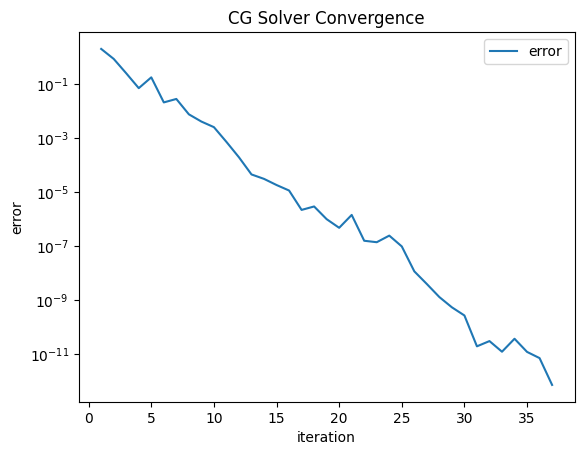

<Figure size 640x480 with 0 Axes>

In [11]:
invS = solvers.CGSolver(S, pre=pre, plotrates=True, maxiter=500)

lam = g.CreateVector()
lam.data = invS * g
gfu.vec.data = ainv * (f.vec - b.mat.T * lam)

In [12]:
Draw(gftot, mesh);

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…